In [42]:
import torch 
from simple_mlp import*
import numpy as np
import shap
import pandas as pd
import pickle
import matplotlib.pyplot as plt

In [6]:
model = simple_mlp()
model.eval()

simple_mlp(
  (fc1): Linear(in_features=5, out_features=20, bias=True)
  (tanh1): Tanh()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)

In [16]:
with open('/Users/racheliritani/Desktop/AD Project/mm-vae/results_DIET/CGMVAE_cfc_cond_5bins_5dim/mlp_15000/Test/y_scaler.pkl', 'rb') as file:
    loaded_y_scaler = pickle.load(file)

In [34]:
def predict(X):
    X_tensor = torch.from_numpy(X).float()
    with torch.no_grad(): 
        scaled_output_tensor = model(X_tensor)

    scaled_output_np = scaled_output_tensor.numpy()
    output_tensor = loaded_y_scaler.inverse_transform(scaled_output_np)
    
    return output_tensor.reshape(-1)

In [11]:
background_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/train_df.csv')
background_data

,LV1,LV2,LV3,LV4,LV5
0,1.648254,1.558364,1.450668,1.713205,1.723632
1,-0.794890,-1.137012,-1.105946,-0.938151,-0.875722
2,-0.348093,-0.264138,-0.208897,-0.409450,-0.600421
3,0.956853,1.063802,1.653756,1.514652,1.608262
4,1.407127,1.454008,1.323928,1.397264,1.267337
...,...,...,...,...,...
398,-0.890301,-0.859367,-0.897388,-0.965282,-0.967811
399,-0.481943,-0.825826,-0.808517,-0.631954,-0.711390
400,1.344620,1.542254,1.234269,1.474108,1.414498
401,0.919085,0.931402,1.518434,1.483853,1.381329


In [12]:
labeled_test_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/test_df.csv')
labeled_test_data

,LV1,LV2,LV3,LV4,LV5
0,-0.779477,-1.006964,-1.136173,-0.955843,-1.038385
1,1.396246,1.485299,1.086567,1.356011,1.343491
2,0.936854,1.069118,1.553280,1.241236,1.368214
3,1.430921,1.202083,0.805948,1.062807,0.937808
4,-0.028423,0.109534,0.292961,0.153503,0.165453
...,...,...,...,...,...
96,-0.732479,-0.975201,-1.064308,-0.914710,-0.946664
97,-1.541691,-1.277772,-1.352743,-1.362469,-1.229207
98,-0.254710,-0.284329,-0.224818,-0.390014,-0.495432
99,0.868306,1.062915,1.397689,1.107768,0.974521


In [13]:
unlabeled_test_data = pd.read_csv('/Users/racheliritani/Desktop/AD Project/mm-vae/cfc_pred/shap_analysis/unlabeled_test_df.csv')
unlabeled_test_data

,LV1,LV2,LV3,LV4,LV5
0,-1.449805,-1.244528,-1.238562,-1.293867,-1.095377
1,-1.511855,-1.224871,-1.202388,-1.259416,-0.967077
2,-1.406277,-1.225478,-1.252526,-1.239374,-1.045401
3,-1.623047,-1.329942,-1.370664,-1.418113,-1.194326
4,-1.578928,-1.302376,-1.322872,-1.375060,-1.162996
...,...,...,...,...,...
428,-0.305777,-0.226051,-0.116640,-0.270936,-0.308718
429,-1.432981,-1.191596,-1.283823,-1.304043,-1.149230
430,-0.529433,-0.857261,-0.940015,-0.705236,-0.864244
431,-0.626058,-0.829345,-1.075658,-0.832502,-1.024606


In [14]:
background_data_np = background_data.values
labeled_test_data_np = labeled_test_data.values
unlabeled_test_data_np = unlabeled_test_data.values 

In [18]:
background_data_np

array([[ 1.64825375,  1.558364  ,  1.45066815,  1.71320516,  1.7236318 ],
       [-0.79488974, -1.13701173, -1.10594627, -0.93815119, -0.87572187],
       [-0.34809295, -0.26413794, -0.20889729, -0.4094502 , -0.60042118],
       ...,
       [ 1.34461989,  1.54225437,  1.23426929,  1.47410776,  1.41449772],
       [ 0.91908508,  0.9314019 ,  1.51843402,  1.48385316,  1.38132892],
       [ 2.2095612 ,  0.79595927,  0.43743669,  0.611535  ,  0.46076394]])

In [35]:
explainer = shap.KernelExplainer(
    model = predict, 
    data = background_data_np
)

Using 403 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [21]:
unlabeled_test_data_np

array([[-1.44980497, -1.24452849, -1.23856205, -1.29386655, -1.09537693],
       [-1.51185471, -1.2248709 , -1.20238756, -1.25941617, -0.96707731],
       [-1.40627662, -1.2254775 , -1.25252592, -1.23937351, -1.04540067],
       ...,
       [-0.52943296, -0.85726064, -0.94001517, -0.7052362 , -0.86424383],
       [-0.62605812, -0.82934459, -1.07565767, -0.8325016 , -1.02460641],
       [-1.36535532, -1.15222507, -1.20837399, -1.18743123, -1.19342453]])

In [22]:
background_data_np.shape

(403, 5)

In [23]:
unlabeled_test_data_np.shape

(433, 5)

In [36]:
shap_values = explainer.shap_values(
    X=unlabeled_test_data_np, 
    nsamples="auto"
)

100%|██████████| 433/433 [00:00<00:00, 545.72it/s]


In [47]:
shap_values.shape

(433, 5)

In [50]:
avg_shap_values = np.mean(np.abs(shap_values), axis=0)
avg_shap_values

array([0.73164108, 0.17886729, 1.68632998, 2.01580303, 1.81895754])

In [38]:
latent_columns = ['LV1', 'LV2', 'LV3', 'LV4', 'LV5']

Text(0.5, 1.0, 'SHAP feature importance for unlabeled test CFC predictions')

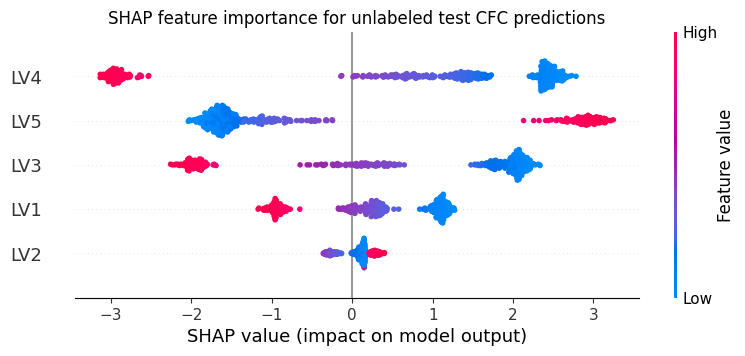

In [44]:
shap.summary_plot(shap_values, unlabeled_test_data_np, feature_names=latent_columns, show=False)
plt.title('SHAP feature importance for unlabeled test CFC predictions')

In [40]:
shap_values_labeled_test = explainer.shap_values(
    X=labeled_test_data_np, 
    nsamples="auto"
)

100%|██████████| 101/101 [00:00<00:00, 394.69it/s]


Text(0.5, 1.0, 'SHAP feature importance for test data')

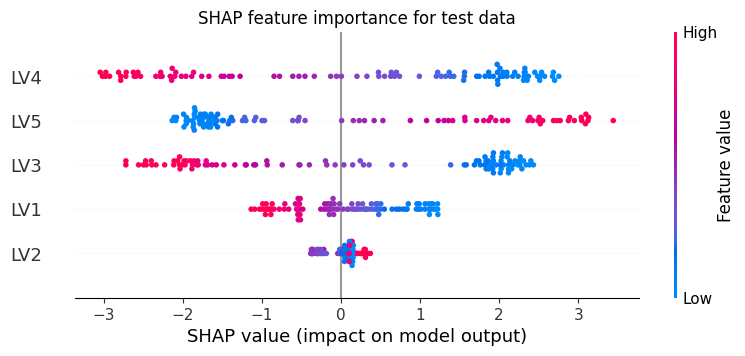

In [45]:
shap.summary_plot(shap_values_labeled_test, labeled_test_data_np, feature_names=latent_columns, show=False)
plt.title('SHAP feature importance for test data')

## SHAP analysis for C-GMVAE data